In [1]:
#############################################
## MATPLOTLIB FEATURES
%matplotlib inline
import matplotlib 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
font = {'weight' : 'bold','size'   : 22}
mpl.rc('font', **font)
mpl.rc('font',   size=209)  #set defaults so that the plots are readable
mpl.rc('axes',   titlesize=20)
mpl.rc('axes',   labelsize=20)
mpl.rc('xtick',  labelsize=20)
mpl.rc('ytick',  labelsize=20)
mpl.rc('legend', fontsize =20)
mpl.rc('figure', titlesize=20)
mpl.rc('text',   usetex=True)
## FURTHER MATPLOTLIB FEATURES
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
colors = ['black','darkgrey', '#0000ff', '#ff0000', '#0000FF',  '#FF0000', '#069AF3', '#00008B','#C79FEF','#DC143C','#C875C4','#9A0EEA','darkorange','#C79FEF','#7E1E9C','silver','#FF7F50','#FC5A50',
          '#FFA500','#F97306','#FFD700','#DDA0DD','#00008B','#069AF3','#0000FF','#00FFFF','#13EAC9','#7FFFD4','#04D8B2','#40E0D0']
my_cmap = ListedColormap(colors, name="my_cmap")
font_dict = {'family': 'serif', 'color':  None,  'weight': 'bold','size': 30}
#############################################
import os,sys,time,platform
from copy import deepcopy as dcopy
from scipy import interpolate
import numpy as np
from scipy import integrate
import healpy as hp
import camb
from camb import model, initialpower
#############################################
import warnings
warnings.filterwarnings("ignore")
#############################################
#PATH TO SCRIPTS FOLDER
path = '/data/AMARINS/CMBWLxHI-CODES/scripts/'
sys.path.insert(1, path)
import cross_functions_theory      as cxft

In [2]:
#definitions
c_light = 299792458/1e3 #km/s
nu_HI  = 1420.405751768 #MHz

In [3]:
def THI_factor_constants():
    G_chbar  = 6.70883e-39 #(GeV/c2)-2
    G_kg     = 6.67430e-11 #N m2/kg2 #m3/kg/s2
    hP_kg    = 6.62607015e-34 #m2 kg s
    kB_kg    = 1.380649e-23 #m2 kg s-2 K-1
    c_light  = 299792458 #m s-1
    mP       = 1.67262192e-24 #g
    mHI_u    = 1.00784 #u
    u_g      = 1.66054e-24 #g
    A10      = 2.85e-15 #s-1
    H0       = 67.4 #km/s/Mpc.
    Mpc_m    = 3.0857e22 # m
    factor   = 9/(256*np.pi**2)
    nu_MHz   = 1420.405751768 #MHz
    N        = 1 #kg m/s2

    kB     = kB_kg*1e3
    hP     = hP_kg*1e3
    G      = G_kg/1e3
    mHI    = mHI_u*u_g
    H0_ms  = H0*(1e3/Mpc_m)
    nu     = nu_MHz*1e6
    nu2    = nu**2
    c3     = c_light**3
    h      = H0/100. #admensional 
    fac   = factor*(hP*c3*A10*H0_ms)/(G*kB*nu2*mHI)
    fac_h = factor*(hP*c3*A10)/(G*kB*nu2*mHI)*(100*(1e3/Mpc_m))
    return fac_h

In [4]:
def z_hi_survey(hi_survey='LOWZ'):
    if hi_survey.upper()=='LOWZ':
        nu_vec = np.linspace(980,1260,30+1) 
    elif hi_survey.upper()=='HIGHZ':
        nu_vec = np.linspace(350,1050,70+1)
    else:
        raise NameError('No survey named {}'.format(hi_survey))
    return np.flip((nu_HI/nu_vec)-1)

def omegaHI_biasHI(model="jiajun",z=None):
    if model=="jiajun": #valido para z < 1.#Zhang et al 2022
        return {"omegaHI":{"HOD":2.7e-4 + 1e-4*z - 8e-5*z**2,
                           "HAM":2.5e-4 - 4e-5*z - 7e-5*z**2}
               }
    if model=="padmanabhan":#padmanabhan 2015
        z = np.array(  [0.000, 0.250, 0.500, 0.750, 1.000, 1.250, 1.500, 1.750, 2.000, 2.250, 2.500, 2.750, 3.000, 3.250, 3.400])
        oHI = np.array([3.344, 3.443, 4.523, 4.648, 4.710, 4.804, 4.766, 4.804, 4.936, 5.008, 4.750, 5.471, 5.541, 5.756, 5.971])
        bHI = np.array([0.703, 0.972, 1.026, 0.935, 1.005, 1.005, 1.049, 1.099, 1.101, 1.160, 1.261, 1.409, 1.329, 1.498, 1.802])        
        return {"z":z, "omegaHI":oHI, "bias":bHI}
    if model=="cunnington":#cunnington2019
        return {"omegaHI":0.00048 + 0.00039*z - 0.000065*z**2}
    if model=="irfan":#Irfan2021 baseado em bull2015 #o mesmo que IRFAN2021
        omegaHI_0 = 4.86e-4 #Irfan2021
        biasHI_0 = 0.677105 #Irfan2021
        return {"omegaHI": (omegaHI_0/4.86)*(4.8304 + 3.8856*z - 0.65119*z**2) ,
                "biasHI" : (biasHI_0/0.677105)*(0.66655 + 0.17765*z + 0.050223*z**2)}
    if model=="crighton":#carucci2020
        omegaHI_0 = 4e-4 #Irfan2021
        biasHI_0  = 0.3 #Irfan2021        
        return {"omegaHI": omegaHI_0*(1+z)**(0.6) ,
                "biasHI" : biasHI_0*(1+z)+0.6}
    else:
        return {"omegaHI": 4.86e-4,
                "biasHI" : 1}   
    
def hi_brightness_temperature(camb_params=None, camb_results=None, z=None, model = None, fit_OHI=False, OHI=None):
    fact = (1+z)**2/(camb_results.hubble_parameter(z)/camb_params.H0)
    if not fit_OHI or type(OHI)==type(None):     
        model = None
        oHI   = omegaHI_biasHI(model=model,z=z)['omegaHI']*camb_params.h
    else: 
        oHI = OHI**camb_params.h
    fact = fact*188.8#(THI_factor_constants()/1e-3)
    return fact*oHI #mK

def window_1(z=None, zmin=None, zmax=None):
    if (z>=zmin)*(z<=zmax): 
        return 1/(zmax-zmin)
    else: 
        return 0

def window_2(value=None, arr=None):
    #arr: array containing the binned redshift
    #value: a specific redshift to be evaluated
    if (value>=arr.min())*(value<=arr.max()):
        vleft =np.sort(arr[np.where(arr<=value)[0]])[-1]#first number to left
        vright=np.sort(arr[np.where(arr>=value)[0]])[0 ]#first number to right
        return window_1(z=value, zmin=np.minimum(vleft,vright), zmax=np.maximum(vleft,vright))
    else:
        return 0

In [5]:
def survey_parameters(survey_name = 'LSST', data_release='Y1'):
    
    if survey_name.upper()=='LSST':
        #firecrown lsst_desc_parameters.yaml
        # https://arxiv.org/pdf/1809.01669
        # https://www.lsst.org/sites/default/files/docs/sciencebook/SB_3.pdf
        
        #limiting_magnitude: limiting magnitude in i-band
        #sigma_z:            photo-z variance (scatter = 0.03 (1 + z))
        #z_bias:             redshift bias values (5 lens bins)
        #n_tomo_bins:        number of tomographic bins
        #bin_start:          start of the lens bin redshift range (z_start < z < z_stop)
        #bin_stop:           end value of the lens bin range (z_start < z < z_stop)
        #bin_spacing:        tomographic bin spacing
        #beta:               power law index of the prefactor (check eq.5 in the SRD paper)
        #alpha:              power law index in the exponent (check eq. 5 in the SRD paper)
        #z_0:                pivot redshift (check eq. 5 in the SRD paper)
        #n_gal:              number density of galaxies per arcmin^2
        #galaxy_bias_prefactor: check page 48 of the SRD b(z) = 1.05 / growth_factor(z)
        #z_start:            start of the redshift interval
        #z_stop:             end of the redshift interval
        #z_resolution:       redshift resolution        
        bin_start = 0.2
        bin_stop  = 1.2
        if data_release.upper()=='Y1':
            #'z0':0.13, 'alpha': 0.78, REF:
            bin_spacing = 0.2
            bin_range = np.arange(bin_start, bin_stop+bin_spacing, bin_spacing)
            return {'survey':survey_name, 'data_release':data_release,
                    'z_0':0.26, 'alpha': 0.94,'beta':2,
                    'limiting_magnitude': 24.1, 'sigma_z':0.03, 'z_bias':0, 'n_tomo_bins':5,
                    'bin_start':bin_start, 'bin_stop':bin_stop, 'bin_spacing':bin_spacing,'bin_range':bin_range,
                    'n_gal':18, 'galaxy_bias_prefactor':1.05, 'galaxy_bias_values': np.array([-1.562362,-1.732963,-1.913252,-2.100644,-2.293210]),
                    'z_min':0.01, 'z_max':3.5, 'z_resolution': 300}
        elif data_release.upper()=='Y10':
            bin_spacing = 0.1
            bin_range = np.arange(bin_start, bin_stop+bin_spacing, bin_spacing)            
            return {'survey':survey_name, 'data_release':data_release,
                    'z_0':0.28, 'alpha': 0.900,'beta':2,
                    'limiting_magnitude': 25.3, 'sigma_z':0.03, 'z_bias':0, 'n_tomo_bins':10,
                    'bin_start':bin_start, 'bin_stop':bin_stop, 'bin_spacing':bin_spacing,'bin_range':bin_range,
                    'n_gal':48, 'galaxy_bias_prefactor':0.95, 'galaxy_bias_values': np.array([-1.376695,-1.451179,-1.528404,-1.607983,-1.689579,-1.772899,-1.857700,-1.943754,-2.030887]),
                    'z_min':0.01, 'z_max':3.5, 'z_resolution': 300}                    
        else:
            bin_spacing = 0.1
            bin_range = np.arange(bin_start, bin_stop+bin_spacing, bin_spacing)            
            return {'survey':survey_name, 'data_release':data_release,
                    'z_0':0.28, 'alpha': 0.900,'beta':2,
                    'limiting_magnitude': 25.3, 'sigma_z':0.03, 'z_bias':0, 'n_tomo_bins':10,
                    'bin_start':bin_start, 'bin_stop':bin_stop, 'bin_spacing':bin_spacing,'bin_range':bin_range,
                    'n_gal':48, 'galaxy_bias_prefactor':0.95, 'galaxy_bias_values': np.array([-1.376695,-1.451179,-1.528404,-1.607983,-1.689579,-1.772899,-1.857700,-1.943754,-2.030887]),
                    'z_min':0.01, 'z_max':3.5, 'z_resolution': 300}                    
    elif survey_name.upper()=='EUCLID':
        #AC. Deshpande et al 2023; A. Blanchard et al 2020
        #Euclid Collaboration et al.: Euclid preparation: VII. Forecast validation for Euclid cosmological probe
        #https://arxiv.org/pdf/1910.09273, pag 24
        #z_edges: they are the limit values of each redshift bin
        #zm:  median redshift
        z_edges = np.array([0.001, 0.418, 0.560, 0.678, 0.789, 0.900, 1.019, 1.155, 1.324, 1.576, 2.50])
        zm = 0.9
        return {'survey':survey_name, 'data_release':data_release,
                'alpha':2, 'beta':1.5, 'z_m':zm, 'z_0':zm/np.sqrt(2),
                'z_min':np.amin(z_edges),'z_max':np.amax(z_edges), 'z_edges':z_edges, 'nbins':z_edges.size-1,
                'c_b':1, 'c_0':1, 'sigma_b':0.05, 'sigma_0':0.05, 'z_b':0, 'z_0':0.1, 'f_out':0.01}
    elif survey_name.upper()=='SKA':
        if data_release.upper()=='Medium-Deep':
            #SKA book - d bacon 2019
            return {'survey':survey_name, 'data_release':data_release,
                    'Asky':5000,'ngal':2.7,'z_m':1.1,'alpha':1.25,'beta':2,'fspec_z':0.15,'zspec_max':0.6,'sigma_z':0.05, 'z_max':2.0, 'sigma_no_z':0.3}            
    elif survey_name.upper()=='DES':
        if data_release.upper()=='5yr':
            #SKA book - d bacon 2019
            return {'survey':survey_name, 'data_release':data_release,
                    'Asky':5000,'ngal':12, 'z_m':0.6,'alpha':1.5,'beta':2,'fspec_z':0.0,'zspec_max':0,'sigma_z':0.05, 'z_max':2.0, 'sigma_no_z':0.3}                    
            
    elif survey_name.upper()=='CFHT':
        if data_release.upper()=='LENS': #CFHTLenS
            # P Taylor et al 2019 [Cosmic Shear: Inference from Forward Models]
            # L Van Waerbeke et al 2013 [CFHTLenS: mapping the large-scale structure with gravitational lensing]
            return {'survey':survey_name, 'data_release':data_release,
                    'a1':1.5,'b1':0.32,'c1':0.2,'d1':0.46,'c_tilde':1,'z_tilde':0,'A':0.05}
        elif data_release.upper()=='CS82': #CFHT Stripe82 Survey
            # L Fu et al 2013 [https://arxiv.org/pdf/0712.0884]
            # N Hand et al 2014 [https://arxiv.org/pdf/1311.6200]
            return {'survey':survey_name, 'data_release':data_release,
                    'z_max':6, 'A':1.555, 'a':0.612, 'b':8.125, 'c':0.620}
        else:
            raise NameError
    elif survey_name.upper()=='RCSLENS':    
        # JHDeraps et al 2016 [https://arxiv.org/pdf/1603.07723]
        # A Hojjati et al 2017 [Cross-correlating Planck tSZ with RCSLenS weak lensing: implicationsfor cosmology and AGN feedback]
        return {'survey':survey_name, 'data_release':data_release,
                'a':2.94, 'b':-0.44, 'c':1.03,'d':1.58, 'e':0.40, 'f':0.25, 'g':0.38, 'h':0.81, 'i':0.12 }
    else:
        raise NameError

In [6]:
def prob_euclid_vec(z_=None,zp_=None,lens_pars=None):
    fout  =lens_pars['f_out']#0.1
    cb    =lens_pars['c_b']#1.0
    c0    =lens_pars['c_0']#1.0
    zb    =lens_pars['z_b']#0.0
    z0    =lens_pars['z_0']#0.1
    sigmab=lens_pars['sigma_b']#0.05
    sigma0=lens_pars['sigma_0']#0.05

    prob_ph1 = ((1-fout)/(np.sqrt(2*np.pi)*sigmab*(1+z_)))*(-0.5*((z_-cb*zp_-zb)/(sigmab*(1+z_)))**2)
    prob_ph2 = ((0+fout)/(np.sqrt(2*np.pi)*sigmab*(1+z_)))*(-0.5*((z_-c0*zp_-z0)/(sigma0*(1+z_)))**2)
    return prob_ph1+prob_ph2

def prob_euclid_func(zp=None,lens_pars=None):
    fout  =lens_pars['f_out']#0.1
    cb    =lens_pars['c_b']#1.0
    c0    =lens_pars['c_0']#1.0
    zb    =lens_pars['z_b']#0.0
    z0    =lens_pars['z_0']#0.1
    sigmab=lens_pars['sigma_b']#0.05
    sigma0=lens_pars['sigma_0']#0.05
    prob_ph1 = lambda x: ((1-fout)/(np.sqrt(2*np.pi)*sigmab*(1+x)))*(-0.5*((x-cb*zp-zb)/(sigmab*(1+x)))**2)
    prob_ph2 = lambda x: ((0+fout)/(np.sqrt(2*np.pi)*sigmab*(1+x)))*(-0.5*((x-c0*zp-z0)/(sigma0*(1+x)))**2)
    return lambda x: prob_ph1(x) + prob_ph2(x)

def prob_lsst_func(zp=None, lens_pars=None):
    from scipy import special
    sigma_z = lambda x: (1+x)*lens_pars['sigma_z']
    NZ_lsst = lambda x: 0.5*special.erfc(- x/(np.sqrt(2)*sigma_z(x)))
    return lambda x: np.exp(-0.5*((x-zp)/sigma_z(x))**2)/(NZ_lsst(x)*np.sqrt(2*np.pi)*sigma_z(x))

def nz_spec(lens_pars=None):
    #Smail distribution for faint galaxies
    return lambda x: (x/lens_pars['z_0'])**lens_pars['beta']*np.exp((x/lens_pars['z_0'])**lens_pars['alpha'])

def nz_convolved(zp=None, lens_pars=None):
    if lens_pars['survey'].upper()=='LSST': 
        #https://arxiv.org/pdf/1812.05995, pg 14, Eqs 69-70
        return lambda x: prob_lsst_func(  zp=zp, lens_pars=lens_pars)(x)*nz_spec(lens_pars=lens_pars)(x)   
    elif lens_pars['survey'].upper()=='EUCLID': 
        return lambda x: prob_euclid_func(zp=zp, lens_pars=lens_pars)(x)*nz_spec(lens_pars=lens_pars)(x)       
    else:
        raise NameError
    
def dNdz_func(lens_pars=None, verbose=False):
    #integrate.dblquad( lambda y, x: dydx f(x.y), x0,x1,y0,y1 )
    if verbose: timei = time.time()
    nch   = lens_pars['bin_range'].size-1 
    zbins = lens_pars['bin_range']
    norms = np.array([ integrate.dblquad( lambda y, x: nz_convolved(zp=x,lens_pars=lens_pars)(y),\
                                         lens_pars['z_min'],lens_pars['z_max'],\
                                         zbins[i],zbins[i+1])[0]  for i in range(nch) ])
    zrange = np.linspace(lens_pars['z_min'], lens_pars['z_max'], 1000)
    for i in range(nch):
        zi_min = zbins[i]
        zi_max = zbins[i+1]
        dNdz_ivec = np.array([ integrate.quad(lambda x : nz_convolved(zp=x,lens_pars=lens_pars)(y), zi_min, zi_max)[0]/norms[i] for y in zrange ])
        if not i: dNdz_vec = dcopy(dNdz_ivec)
        else:     dNdz_vec = np.vstack((dNdz_vec, dcopy(dNdz_ivec)))    
    if verbose: print('Total processing time: {0:.2f} seg'.format(time.time()-timei)) 
    return {'dNdz':dNdz_vec, 'z':zrange}

In [7]:
  
def chi_vec(camb_results=None): #radial comovel distance
    from scipy import interpolate
    zv         = np.linspace(0,1200)
    rv         = camb_results.comoving_radial_distance(zv)
    z_chi      = interpolate.interp1d(rv, zv, kind='linear') #function
    z_star     = camb_results.get_derived_params()['zstar']
    chi_star   = camb_results.comoving_radial_distance(z_star)
    #zs         = results.redshift_at_comoving_radial_distance(np.linspace(0,chi_star,nz))
    z_chi_camb = lambda y: results.redshift_at_comoving_radial_distance(y)    
    return {'zvec':zv, 'chivec':rv, 'z_chi': z_chi, 'z_chi_camb':z_chi_camb, 'z_star':z_star, 'chi_star':chi_star}

def kernel_hi_dict(z_survey=None, camb_params=None, camb_results=None,config_dict=None, replace_inf2nan=False):
    #2set higher z-range, with 0
    Khi_all= np.array([])
    Z_all  = np.array([])
    for i in np.arange(z_survey.size-1):
        zmin = z_survey[i]
        zmax = z_survey[i+1]
        z_range = np.linspace(zmin,zmax,100)
        for j,zj in enumerate(z_range):
            if not j: 
                khi = kernel_hi(camb_params=camb_params, camb_results=camb_results, z=zj, zrange=z_survey, config_dict=config_dict, replace_inf2nan=replace_inf2nan)
                #khi = kernel_hi_vec(camb_params=camb_params, camb_results=camb_results, z=zj, zmin = zmin, zmax=zmax)
            else:
                khi = np.hstack(( khi,kernel_hi(camb_params=camb_params, camb_results=camb_results, z=zj, zrange=z_survey, config_dict=config_dict, replace_inf2nan=replace_inf2nan) ))
                #khi = np.hstack((khi,kernel_hi_vec(camb_params=camb_params, camb_results=camb_results, z=zj, zmin = zmin, zmax=zmax)))
        Khi_all = np.hstack((Khi_all,khi))
        Z_all   = np.hstack((Z_all,z_range))
        if not i:
            Khi_dict = {str(i+1):khi}
            Khi_vec  = khi
            Z_dict   = {str(i+1):z_range}
            Z_vec    = z_range
        else:
            Khi_dict[str(i+1)] = khi 
            Khi_vec = np.vstack(( Khi_vec,khi ))
            Z_dict[str(i+1)]   = z_range 
            Z_vec  = np.vstack(( Z_vec,z_range ))    
    #dNdz_intp = interp1d(dNdz_vec['z'], dNdz_vec['dNdz'][j,:], kind='cubic')
    return {'kernel_vec' :Khi_vec , 'z_vec' :Z_vec,
            'kernel_dict':Khi_dict, 'z_dict':Z_dict,
            'kernel_all' :Khi_all , 'z_all' :Z_all}


def kernel_hi(camb_params=None, camb_results=None, z=None, zrange=None, config_dict=None, replace_inf2nan=False):
    #model=None, fit_bHI=False, bHI=None, fit_OHI=False, OHI=None):
    #zrange: array of z bins of the survey (not the whole z analyzed)
    #z: value to be analyzed (in/out zrange)
    omegaHI_model = config_dict['OmegaHI_model']
    biasHI_model  = config_dict['biasHI_model']
    fit_bHI = config_dict['fit_biasHI']
    fit_OHI = config_dict['fit_OmegaHI']
    bHI = config_dict['biasHI']
    OHI = config_dict['OmegaHI']
    #if you choice to determine (fit) HI bias (bHI) and Omega HI (OHI), 
    #you must to specify True for the fit_bHI (fit_OHI) parameter and to set the parameter value
    #otherwise, the code will assume the model provided.
    w1 = window_2(value=z, arr=zrange)#selection function
    #print(config_dict)
    #print(w1)
    if not w1: return 0
    THI = hi_brightness_temperature(camb_params=camb_params, camb_results=camb_results, z=z, model=omegaHI_model, fit_OHI=fit_OHI, OHI=OHI)
    if not fit_bHI or type(bHI)==type(None): 
        bHI = omegaHI_biasHI(model=biasHI_model,z=z)['biasHI']
    else:
        pass
    if replace_inf2nan and (bHI*THI*w1 == np.inf): return np.nan
    else: return bHI*THI*w1 

In [8]:
def chi_vec(camb_results=None): #radial comovel distance
    from scipy import interpolate
    zv         = np.linspace(0,1200)
    rv         = camb_results.comoving_radial_distance(zv)
    z_chi      = interpolate.interp1d(rv, zv, kind='linear') #function
    z_star     = camb_results.get_derived_params()['zstar']
    chi_star   = camb_results.comoving_radial_distance(z_star)
    #zs         = results.redshift_at_comoving_radial_distance(np.linspace(0,chi_star,nz))
    z_chi_camb = lambda y: results.redshift_at_comoving_radial_distance(y)    
    return {'zvec':zv, 'chivec':rv, 'z_chi': z_chi, 'z_chi_camb':z_chi_camb, 'z_star':z_star, 'chi_star':chi_star}

def kernel_hi_dict(z_survey=None, camb_params=None, camb_results=None,config_dict=None, replace_inf2nan=False):
    #2set higher z-range, with 0
    Khi_all= np.array([])
    Z_all  = np.array([])
    for i in np.arange(z_survey.size-1):
        zmin = z_survey[i]
        zmax = z_survey[i+1]
        z_range = np.linspace(zmin,zmax,100)
        for j,zj in enumerate(z_range):
            if not j: 
                khi = kernel_hi(camb_params=camb_params, camb_results=camb_results, z=zj, zrange=z_survey, config_dict=config_dict, replace_inf2nan=replace_inf2nan)
                #khi = kernel_hi_vec(camb_params=camb_params, camb_results=camb_results, z=zj, zmin = zmin, zmax=zmax)
            else:
                khi = np.hstack(( khi,kernel_hi(camb_params=camb_params, camb_results=camb_results, z=zj, zrange=z_survey, config_dict=config_dict, replace_inf2nan=replace_inf2nan) ))
                #khi = np.hstack((khi,kernel_hi_vec(camb_params=camb_params, camb_results=camb_results, z=zj, zmin = zmin, zmax=zmax)))
        Khi_all = np.hstack((Khi_all,khi))
        Z_all   = np.hstack((Z_all,z_range))
        if not i:
            Khi_dict = {str(i+1):khi}
            Khi_vec  = khi
            Z_dict   = {str(i+1):z_range}
            Z_vec    = z_range
        else:
            Khi_dict[str(i+1)] = khi 
            Khi_vec = np.vstack(( Khi_vec,khi ))
            Z_dict[str(i+1)]   = z_range 
            Z_vec  = np.vstack(( Z_vec,z_range ))    
    #dNdz_intp = interp1d(dNdz_vec['z'], dNdz_vec['dNdz'][j,:], kind='cubic')
    return {'kernel_vec' :Khi_vec , 'z_vec' :Z_vec,
            'kernel_dict':Khi_dict, 'z_dict':Z_dict,
            'kernel_all' :Khi_all , 'z_all' :Z_all}


def kernel_hi(camb_params=None, camb_results=None, z=None, zrange=None, config_dict=None, replace_inf2nan=False):
    #model=None, fit_bHI=False, bHI=None, fit_OHI=False, OHI=None):
    #zrange: array of z bins of the survey (not the whole z analyzed)
    #z: value to be analyzed (in/out zrange)
    omegaHI_model = config_dict['OmegaHI_model']
    biasHI_model  = config_dict['biasHI_model']
    fit_bHI = config_dict['fit_biasHI']
    fit_OHI = config_dict['fit_OmegaHI']
    bHI = config_dict['biasHI']
    OHI = config_dict['OmegaHI']
    #if you choice to determine (fit) HI bias (bHI) and Omega HI (OHI), 
    #you must to specify True for the fit_bHI (fit_OHI) parameter and to set the parameter value
    #otherwise, the code will assume the model provided.
    w1 = window_2(value=z, arr=zrange)#selection function
    #print(config_dict)
    #print(w1)
    if not w1: return 0
    THI = hi_brightness_temperature(camb_params=camb_params, camb_results=camb_results, z=z, model=omegaHI_model, fit_OHI=fit_OHI, OHI=OHI)
    if not fit_bHI or type(bHI)==type(None): 
        bHI = omegaHI_biasHI(model=biasHI_model,z=z)['biasHI']
    else:
        pass
    if replace_inf2nan and (bHI*THI*w1 == np.inf): return np.nan
    else: return bHI*THI*w1 

In [9]:
def kernel_cmb_z(z_=None, camb_params=None, camb_results=None,verbose=False):
    if verbose: timei = time.time()
    #wl_pars = survey_parameters(survey_name =survey_name, data_release=data_release)
    #zmin    = 0
    #zmax    = 20#camb_results.get_derived_params()['zstar']  
    #zstar   = camb_results.get_derived_params()['zstar']  
    #chi_zprime = lambda x: results.comoving_radial_distance(x)
    fact    = 1.5*camb_params.omegam*camb_params.H0**2/c_light/camb_results.hubble_parameter(z_)
    chi_z   = results.comoving_radial_distance(z_)
    chi_star = chi_vec(camb_results)['chi_star']
    if verbose: print('Total processing time: {0:.2f} seg'.format(time.time()-timei))          
    return fact*(1+z_)*chi_z*(chi_star-chi_z)/chi_star  

#def kernel_gal_z(zbins=None, camb_params=None, camb_results=None, lens_pars=None, cut_to_bin=False, verbose=False):
def kernel_shear_i_z(z_=None, camb_params=None, camb_results=None, ibin=0, lens_pars=None):#, cut_to_bin=False):
    #ibin: determine which shear galaxy bin is used to calculate the kernel
    #dNdz_vec = dNdz_func(zbins=zbins, lens_pars=lens_pars, verbose=False)
    from scipy.interpolate import interp1d    
    dNdz_vec = dNdz_func(lens_pars=lens_pars, verbose=False)
    z_i         = dNdz_vec['z'][:]
    dNdz_i      = dNdz_vec['dNdz'][ibin,:]
    dNdz_i_intp = interp1d(z_i, dNdz_i, kind='cubic')
    #
    chi      = lambda x: camb_results.comoving_radial_distance(x)    
    fact_z   = lambda y: 1.5*camb_params.omegam*camb_params.H0**2/c_light/camb_results.hubble_parameter(y)*(1+y)*chi(y)
    #
    return fact_z(z_)*integrate.quad(lambda x: dNdz_i_intp(x)*( (chi(x)-chi(z_))/chi(x) ), z_, lens_pars['z_max'])[0]

def kernel_shear_i(camb_params=None, camb_results=None, ibin=0, lens_pars=None, verbose=False):#,cut_to_bin=False, ):
    if verbose: timei = time.time()    
    zi_range = np.linspace(lens_pars['z_min'], lens_pars['z_max'],300)
    igx      = np.array([ kernel_shear_i_z(z_=zi, camb_params=camb_params, camb_results=camb_results, ibin=ibin, lens_pars=lens_pars) for zi in zi_range ])
    if verbose: print('Total processing time: {0:.2f} seg'.format(time.time()-timei))  
    return igx

def kernel_shear(camb_params=None, camb_results=None, lens_pars=None, verbose=False):#,cut_to_bin=False, ):
    if verbose: timei = time.time()    
    #zi_range = np.linspace(lens_pars['z_min'], lens_pars['z_max'],300)
    dNdz_vec = dNdz_func(lens_pars=lens_pars, verbose=False)
    for ibin in range(lens_pars['bin_range'].size-1):
        if not ibin:
            kshear = kernel_shear_i(camb_params=camb_params, camb_results=camb_results, ibin=ibin, lens_pars=lens_pars)
        else:
            kshear = np.vstack(( kshear,kernel_shear_i(camb_params=camb_params, camb_results=camb_results, ibin=ibin, lens_pars=lens_pars) ))
    if verbose: print('Total processing time: {0:.2f} seg'.format(time.time()-timei))  
    return kshear

In [10]:
def kernel_gal_i_dict(camb_params=None, camb_results=None, lens_pars=None, ibin=False, verbose=False, Np=300):#,cut_to_bin=False, ):
    from scipy.interpolate import interp1d
    if verbose: timei = time.time()    
    #dNdz_vec = dNdz_func(zbins=zbins, lens_pars=lens_pars, verbose=False)
    dNdz_vec = dNdz_func(lens_pars=lens_pars, verbose=False)
    #
    chi_z = lambda x: camb_results.comoving_radial_distance(x)    
    fact  = lambda y: 1.5*camb_params.omegam*camb_params.H0**2/c_light/camb_results.hubble_parameter(y)*(1+y)*chi_z(y)
    ####
    #for j in range(dNdz_vec['dNdz'].shape[0]):
    dNdz_intp = interp1d(dNdz_vec['z'], dNdz_vec['dNdz'][ibin,:], kind='cubic')
    ####
    zi_range = np.linspace(lens_pars['z_min'], lens_pars['z_max'],Np)
    ####
    gx = np.array([ fact(zi)*integrate.quad(lambda x: dNdz_intp(x)*( (chi_z(x)-chi_z(zi))/chi_z(x) ), zi, lens_pars['z_max'])[0] for zi in zi_range ])
    ####
    gx_intp = interp1d(zi_range, gx, kind='cubic')#, fill_value="extrapolate")
    ####
    if verbose: print('Total processing time: {0:.2f} seg'.format(time.time()-timei))             
    return {'W':gx, 'z':zi_range, 'W_interp':gx_intp, 'bin':ibin}


def kernel_gal_dict(camb_params=None, camb_results=None, lens_pars=None, verbose=False):#,cut_to_bin=False, ):
    from scipy.interpolate import interp1d
    if verbose: timei = time.time()    
    #dNdz_vec = dNdz_func(zbins=zbins, lens_pars=lens_pars, verbose=False)
    dNdz_vec = dNdz_func(lens_pars=lens_pars, verbose=False)
    #
    chi_z = lambda x: camb_results.comoving_radial_distance(x)    
    fact  = lambda y: 1.5*camb_params.omegam*camb_params.H0**2/c_light/camb_results.hubble_parameter(y)*(1+y)*chi_z(y)
    ####
    for j in range(dNdz_vec['dNdz'].shape[0]):
        dNdz_intp = interp1d(dNdz_vec['z'], dNdz_vec['dNdz'][j,:], kind='cubic')
        ####
        zi_range = np.linspace(lens_pars['z_min'], lens_pars['z_max'],300)
        ####
        igx = np.array([ fact(zi)*integrate.quad(lambda x: dNdz_intp(x)*( (chi_z(x)-chi_z(zi))/chi_z(x) ), zi, lens_pars['z_max'])[0] for zi in zi_range ])
        if not j:
            gx = dcopy(igx)
            zv_range = dcopy(zi_range)
        else:
            gx = np.vstack(( gx,dcopy(igx) ))
            zv_range = np.vstack(( zv_range, dcopy(zi_range) ))
    if verbose: print('Total processing time: {0:.2f} seg'.format(time.time()-timei))             
    return {'W':gx, 'z':zv_range}     


In [11]:
def kernel_shear_interp_part1(kernel_shear_dict=None, z=None):
    nbins,nls = kernel_shear_dict['z'].shape
    K_dict1 = {}
    for j in range(nbins):
        K_interp = interpolate.interp1d(kernel_shear_dict['z'][j,:], kernel_shear_dict['W'][j,:], kind='cubic') 
        K_func   = K_interp(z) if (z>=kernel_shear_dict['z'][j,:].min())*(z<=kernel_shear_dict['z'][j,:].max()) else 0
        K_dict1[str(j)] = dcopy(K_func)
    return K_dict1

def kernel_shear_interp_part2(kernel_shear_dict=None, zarr=None):
    nbins,nls = kernel_shear_dict['z'].shape    
    K_func = lambda x,y: kernel_shear_interp_part1(kernel_shear_dict, x)[str(y)] 
    for j in range(nbins):
        if not j: K_vec = np.array([K_func(x=ix,y=j) for ix in zarr])
        else:     K_vec = np.vstack(( K_vec, np.array([K_func(x=ix,y=j) for ix in zarr]) ))
    return K_vec

def kernel_cmb_interp(camb_params=None, camb_results=None):
    return lambda zi:  kernel_cmb_z(z_=zi, camb_params=camb_params, camb_results=camb_results)

In [12]:
def angular_power_spectrum_ij(camb_params=None, camb_results=None, W_f1_i=None, W_f2_j=None, l=None, z_min=None, z_max=None, verbose=False):
    #       W_f1_i: kernel of field 1 for i-bin
    #       W_f2_j: kernel of field 2 for j-bin    
    #[z_min,z_max]: integration limits
    timei=time.time()
    for ii, iil in enumerate(l):
        dCdz = lambda x: (camb_results.hubble_parameter(x)/c_light)*\
               pk_interp.P(x,(iil+0.5)/results.comoving_radial_distance(x))*\
               (W_f1_i(x)*W_f2_j(x))/(camb_results.comoving_radial_distance(x)**2)
        cz   = integrate.quad(dCdz, z_min, z_max)[0]   
        if not ii: Cz = dcopy(cz)
        else:      Cz = np.hstack(( Cz, dcopy(cz) ))
        del cz, dCdz
    if verbose: print('Total processing time: {0:.2f} seg'.format(time.time()-timei))   
    return {'l':l,'cl':Cz}

def angular_power_spectrum(W_f1=None, W_f2=None, z_bins=None,camb_results=None, Pk_camb_interp=None, nbins_f1=None, nbins_f2=None, l=None, verbose=1):
    #W_f1: kernel of field 1
    #W_f2: kernel of field 2
    #kernel_f1 (f2) must cover z_bins
    timei=time.time()
    if type(l)==type(None):l=np.arange(1,300+1,1)
    ###############################
    for j in np.arange(z_bins.size-1):
        zmin= z_bins[j]
        zmax= z_bins[j+1]
        cl_ij = angular_power_spectrum_ij(camb_params=camb_params, camb_results=Nocamb_resultsne, W_f1_i=None, W_f2_j=None, l=l, z_min=None, z_max=None)['cl']
        if not j: Cspec = cspec
        else:     Cspec = np.vstack(( Cspec, Cspec ))
        del cspec, dC_dz
    ###############################
    if verbose: print('Total processing time: {0:.2f} seg'.format(time.time()-timei))   
    return {'l':l,'cl':Cspec,'z':z_bins}

In [13]:
#halofit_version
#
#original: astro-ph/0207664
#bird: arXiv:1109.4416
#peacock: Peacock fit
#takahashi: arXiv:1208.2701
#mead: HMCode arXiv:1602.02154
#halomodel: basic halomodel
#casarini: PKequal arXiv:0810.0190, arXiv:1601.07230
#mead2015: original 2015 version of HMCode arXiv:1505.07833
#mead2016: Alias for ‘mead’.
#mead2020: 2020 version of HMcode arXiv:2009.01858
#mead2020_feedback: 2020 version of HMcode with baryonic feedback arXiv:2009.01858

params = { 'H0'   : 67.5,
           'ombh2': 0.022,
           'omch2': 0.122,
           'ns'   : 0.965,
           'z'    : np.logspace(np.log10(1),np.log10(1150), 150),
           'kmax' : 100,
           'minkh': 1e-4,
           'maxkh': 100,
           'npoints': 1e8,
           'nonlinear':True,
           'halofit_version':'mead2020'}       


#pars = camb.CAMBparams()
pars = camb.set_params(halofit_version=params['halofit_version'])#, HMCode_A_baryon=3.13, HMCode_eta_baryon=0.603, HMCode_logT_AGN=7.8)
                       #H0=params['H0'], ombh2=params['ombh2'], omch2=params['omch2'])
pars.set_cosmology(H0=params['H0'], ombh2=params['ombh2'], omch2=params['omch2'])
pars.InitPower.set_params(ns=params['ns'])
pars.set_matter_power(redshifts=params['z'], kmax=params['kmax'])
#pars.NonLinear = model.NonLinear_both
#results.calc_power_spectra(pars)
results   = camb.get_results(pars)
pk_interp = camb.get_matter_power_interpolator(pars, 
                                               nonlinear=params['nonlinear'], hubble_units=False, k_hunit=False, 
                                               kmax=params['kmax'], zmax=params['z'][-1])

Note: redshifts have been re-sorted (earliest first)


In [14]:
z_lowz  = z_hi_survey(hi_survey='LOWZ')
z_highz = z_hi_survey(hi_survey='HIGHZ')

$k^{\|}\leq k_{\textrm{\tiny FG}}\sim (H(z)/c(1+z)^2)\times\pi/\Delta^{\textrm{\tiny tot}}\nu $

In [15]:
params_f2_survey= {'field':'hi',
                           "freq_min":980, "freq_max":1260, "nchannels":30,
                           "z":z_lowz, 'z_min':z_lowz.min(), 'z_max':z_lowz.max(),
                           'OmegaHI_model': None, 'OmegaHI':None, 'fit_OmegaHI':False, 
                           'biasHI_model' : None, 'biasHI' :None, 'fit_biasHI' :False}

params_lowz =   {'field':'hi',
                         "freq_min":980, "freq_max":1260, "nchannels":30,
                         "z":z_lowz, 'z_min':z_lowz.min(), 'z_max':z_lowz.max(),
                         'OmegaHI_model': None, 'OmegaHI':None, 'fit_OmegaHI':False, 
                         'biasHI_model' : None, 'biasHI' :None, 'fit_biasHI' :False}
params_highz = {'field':'hi',
                         "freq_min":350, "freq_max":1050, "nchannels":70,
                         "z":z_highz, 'z_min':z_highz.min(), 'z_max':z_highz.max(),
                         'OmegaHI_model': None, 'OmegaHI':None, 'fit_OmegaHI':False, 
                         'biasHI_model' : None, 'biasHI' :None, 'fit_biasHI' :False}
params_f2_survey.keys()

pars_gshear = survey_parameters(survey_name = 'LSST', data_release= 'Y10')

In [16]:
z=z_highz
pars_hi = params_highz
#####
bwidth = pars_hi["freq_max"]-pars_hi["freq_min"]

(results.hubble_parameter(z)/c_light/(1+z)**2)*(np.pi/bwidth);

In [17]:
Wg   = kernel_gal_dict(camb_params=pars, camb_results=results, lens_pars=pars_gshear, verbose=1)
Wg_i = kernel_gal_i_dict(ibin=0,camb_params=pars, camb_results=results, lens_pars=pars_gshear, verbose=1)

j=201
print(Wg_i['z'][j], np.array(Wg_i['W'][j]), Wg_i['W_interp'](Wg_i['z'][j]))
print(Wg_i['W_interp'](0.5))

Total processing time: 11.43 seg
Total processing time: 3.70 seg
2.3561204013377925 3.7342130703434525e-92 3.734213070343452e-92
1.933908268329857e-08


In [18]:
#Wgamma_func  = dcopy(Wg_i['W_interp'])
Wkappa_func  = kernel_cmb_interp(camb_params=pars, camb_results=results)
Wgamma_func  = lambda x: Wg_i['W_interp'](x) if (x>=pars_gshear['z_min'])*(x<=pars_gshear['z_max']) else 0
W_lowz_func  = lambda x: kernel_hi(camb_params=pars, camb_results=results, z=x, zrange=z_lowz, config_dict=params_lowz, replace_inf2nan=True)
W_highz_func = lambda x: kernel_hi(camb_params=pars, camb_results=results, z=x, zrange=z_highz, config_dict=params_highz, replace_inf2nan=True)
##########
z = 0.5
Wgamma_func(z), Wkappa_func(z), W_lowz_func(z), W_highz_func(z)

(array(1.93390827e-08), 0.20305200584913005, 0, 6.614720717023118)

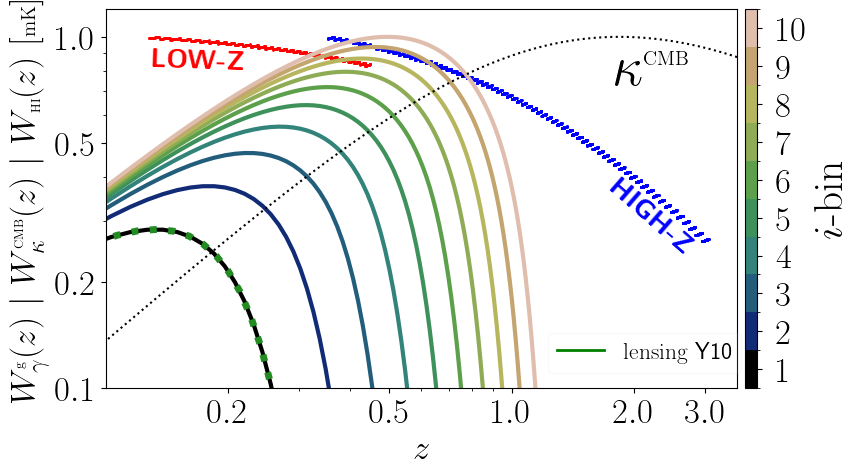

In [19]:
fig   = plt.figure()
grid  = plt.GridSpec(1,1,top=0.9,right=1.3, wspace=0.03)
ax  = plt.subplot(grid[0,0])
#
N=10
nch  = 10#W_dict['W'].shape[0]
cmap = plt.get_cmap("gist_earth", N+1)
#
c    = np.arange(0, nch+1)
norm = mpl.colors.BoundaryNorm(np.arange(1, N+2,1),N)
sm   = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
########
zv = np.linspace(0,4,10000)
Wlowz = np.array([ W_lowz_func(izv) for izv in zv ])
ax.scatter(zv, Wlowz/Wlowz.max(), s=1, c='red')
########
zv = np.linspace(0,4,10000)
Whighz = np.array([ W_highz_func(izv) for izv in zv ])
ax.scatter(zv, Whighz/Whighz.max(), s=1, c='blue')
########
zv = np.linspace(0,4,300)
Wgamma = np.array([ Wgamma_func(izv) for izv in zv ])
wmax = Wg['W'][:,:].max()
for i in range(10): plt.plot(Wg['z'][i,:],Wg['W'][i,:]/wmax, color=cmap(i), ls='solid', lw=3)
ax.plot(zv, Wgamma/wmax, c='forestgreen', ls='dotted', lw=5)
########
zv = np.linspace(0,4,300)
Wkappa= np.array([ Wkappa_func(izv) for izv in zv ])
ax.plot(zv, Wkappa/Wkappa.max(), c='black',ls='dotted')
############################################################
ax.set_xlabel(r"$z$"                      , fontsize =25)
ax.set_ylabel(r"$W$"                      , fontsize =25)
ax.tick_params(axis='both', which='major' , labelsize=25)
ax.set_ylabel(r"$W^{\textrm{\normalsize g}}_{\gamma} (z)\ |\ W^{\textrm{\small CMB}}_{\kappa} (z)\ |\ W_{\textrm{\small HI}} (z)\ {\Large [\textrm{mK}]}$", fontsize=25)  
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(0.1,3.6)

cxticks = [0.2, 0.5, 1.0, 2.0, 3.0]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
#ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim(0.1,1.2)
cyticks = [0.1,0.2, 0.5,1]
ax.set_yticks(cyticks, [r'${:.1f}$'.format(z) for z in cyticks]);
###########################################################
font_dict = {'family': 'serif', 'color':  'black',  'weight': 'bold','size': 40}
ax.text(x=1.8, y=0.73,s=r'$\kappa^{\Large\textrm{CMB}}$', fontdict=font_dict)

font_dict['color']='#0000ff';font_dict['size']=20
ax.text(x=1.7, y=0.24,s=r'$\textbf{HIGH-Z}$', fontdict=font_dict,rotation=-41)

font_dict['color']='#ff0000';font_dict['size']=20
ax.text(x=0.13, y=0.81,s=r'$\textbf{LOW-Z}$', fontdict=font_dict,rotation=-2)
###########################################################
custom_lines = [Line2D([0], [0], color='g', lw=2, ls='solid')]
#
legend_1= ax.legend(custom_lines, [r'$\textrm{lensing}$ '+'{}'.format(pars_gshear['data_release'])],bbox_to_anchor=(1.025, .01),
                    fontsize=17,ncols=1,loc='lower right',framealpha=0.1)
###########################################################
cticks = np.arange(1, N+1,1)#np.linspace(1, len(c)+1, len(c), dtype=np.int8)
cbar   = fig.colorbar(sm,ax=ax, pad=0.01, aspect=30, ticks=cticks+0.5)
#cbar.locator = MaxNLocator(nbins=N)
#cbar.update_ticks()
cbar.set_label(label=r'$i\textrm{-bin}$',size=30)#,weight='bold')
cticks = np.array([r'${}$'.format(i) for i in cticks])
cbar.ax.set_yticklabels(cticks)
cbar.ax.tick_params(labelsize=25, pad=10);
###########################################################

## 1st Consistency test

In [20]:
l=np.arange(1,300+1,1)
#Wgamma_func  = dcopy(Wg_i['W_interp'])
Wkappa_func  = kernel_cmb_interp(camb_params=pars, camb_results=results)
Wgamma_func  = lambda x: Wg_i['W_interp'](x) if (x>=pars_gshear['z_min'])*(x<=pars_gshear['z_max']) else 0
W_lowz_func  = lambda x: kernel_hi(camb_params=pars, camb_results=results, z=x, zrange=z_lowz, config_dict=params_lowz, replace_inf2nan=True)
W_highz_func = lambda x: kernel_hi(camb_params=pars, camb_results=results, z=x, zrange=z_highz, config_dict=params_highz, replace_inf2nan=True)

In [21]:
Cl_lowz = np.array([ angular_power_spectrum_ij(camb_params=pars, camb_results=results, 
                                               W_f1_i=W_lowz_func, W_f2_j=W_lowz_func, l=l, 
                                               z_min= params_lowz['z'][i], z_max= params_lowz['z'][i+1])['cl'] 
                    for i in range(params_lowz['z'].size-1) ])

Cl_highz = np.array([ angular_power_spectrum_ij(camb_params=pars, camb_results=results, 
                                                W_f1_i=W_highz_func, W_f2_j=W_highz_func, l=l, 
                                                z_min= params_highz['z'][i], z_max= params_highz['z'][i+1])['cl'] 
                     for i in range(params_highz['z'].size-1) ])

In [22]:
Cl_kappa =angular_power_spectrum_ij(camb_params=pars, camb_results=results, 
                                                W_f1_i=Wkappa_func, W_f2_j=Wkappa_func, l=l, 
                                                z_min= 0, z_max=1000, verbose=1)['cl']

Total processing time: 6053.65 seg


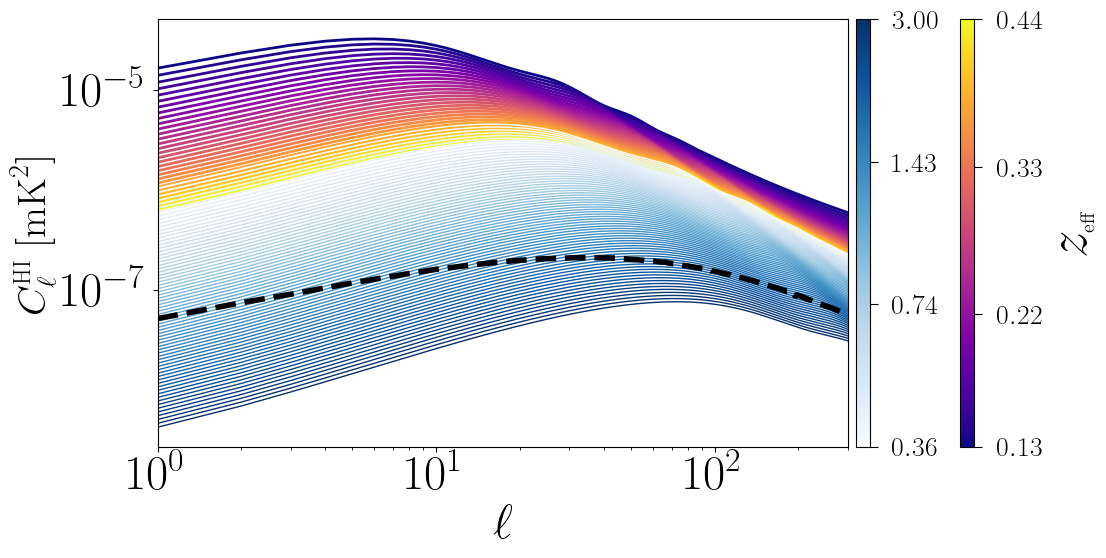

In [23]:
fig   = plt.figure()
grid  = plt.GridSpec(1,1,top=1,right=1.6,wspace=0, hspace=0.0)
ax1   = plt.subplot(grid[0,0])
###############################
n1,N1  = 30,4
n2,N2  = 70,4
c1 = np.linspace(1, n1, N1, dtype=np.int16)-1
norm1 = mpl.colors.Normalize(vmin=1, vmax=int(n1))
c2 = np.linspace(1, n2, N2, dtype=np.int16)-1
norm2 = mpl.colors.Normalize(vmin=1, vmax=int(n2))
cmap1 = plt.get_cmap("plasma")#, N+3)
cmap2 = plt.get_cmap("Blues")#, N+3)
cmap1 = mpl.cm.ScalarMappable(norm=norm1, cmap=cmap1)
cmap2 = mpl.cm.ScalarMappable(norm=norm2, cmap=cmap2)
cmap1.set_array([])
cmap2.set_array([])
#####
A = 1#l*(l+1)  
############################################################################################################
for j,jbin in enumerate( range(Cl_lowz.shape[0]) ):
    ax1.plot(l,A*Cl_lowz[jbin,:],color=cmap1.to_rgba(j+1),lw=2, ls='solid')
    
for j,jbin in enumerate( range(Cl_highz.shape[0]) ):
    ax1.plot(l,A*Cl_highz[jbin,:],color=cmap2.to_rgba(j+1),lw=1, ls='solid')

ax1.plot(l,A*Cl_kappa, color=colors[0], lw=4, ls='dashed')

ax1.tick_params(axis='both', labelsize=35),
ax1.set_yscale('log'); ax1.set_xscale('log')
ax1.set_xlim([1,l.max()])
#ax1.set_ylim(0.2e-14, 8e-6);ax2.set_ylim(0.2e-14, 8e-6)
ax1.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}\ [\textrm{mK}^2]$', fontsize=29); 
ax1.set_xlabel(r'$\ell$', fontsize=35)
ax1.set_xlim([l.min(), l.max()])
############################################################
#colorbar1
zeff      = cxft.get_zeff(numin =980, numax =1260, nbands= n1, n_curves=N1)['zeff']
ibins     = cxft.get_zeff(numin =980, numax =1260, nbands= n1, n_curves=N1)['bins']
cticks    = dcopy(ibins)+1
cbar1 = fig.colorbar(cmap1, ax=ax1, 
                     pad=-0.02, aspect=30, ticks=cticks, 
                     format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar1.ax.tick_params(axis='both', which='major', labelsize=20, length=6, pad=10)

cbar1.set_label( label=r'$z_{\textrm{\Large eff}}$', fontsize=40)
###############
#colorbar2
zeff      = cxft.get_zeff(numin =350, numax =1050, nbands= n2, n_curves=N2)['zeff']
ibins     = cxft.get_zeff(numin =350, numax =1050, nbands= n2, n_curves=N2)['bins']
cticks    = dcopy(ibins)+1

cbar2 = fig.colorbar(cmap2, ax=ax1, 
                     pad=0.01, aspect=30, ticks=cticks,
                     format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar2.ax.tick_params(axis='both', which='major', labelsize=20, length=6, pad=10)

## Shear

In [24]:
ibin=0
Wg   = kernel_gal_dict(camb_params=pars, camb_results=results, lens_pars=pars_gshear, verbose=1)
Wg_i = kernel_gal_i_dict(ibin=ibin,camb_params=pars, camb_results=results, lens_pars=pars_gshear, verbose=1)

Total processing time: 16.60 seg
Total processing time: 5.36 seg


In [25]:
j=201
print(Wg_i['z'][j], np.array(Wg_i['W'][j]), Wg_i['W_interp'](Wg_i['z'][j]))
print(Wg_i['W_interp'](0.5))

2.3561204013377925 3.7342130703434525e-92 3.734213070343452e-92
1.933908268329857e-08


In [26]:
Wgamma_func  = lambda x: Wg_i['W_interp'](x) if (x>=pars_gshear['z_min'])*(x<=pars_gshear['z_max']) else 0

In [27]:
ibin = 0
for i, ibin in enumerate(range(Wg['W'].shape[0])):
    Wg_i = kernel_gal_i_dict(ibin=ibin,camb_params=pars, camb_results=results, lens_pars=pars_gshear, verbose=0)
    Wgamma_func  = lambda x: Wg_i['W_interp'](x) if (x>=pars_gshear['z_min'])*(x<=pars_gshear['z_max']) else 0
    W_f1_i = dcopy(Wgamma_func)
    W_f2_j = dcopy(Wgamma_func)
    z_min = pars_gshear['z_min']
    z_max = pars_gshear['z_max']
    cl_gamma =angular_power_spectrum_ij(camb_params=pars, camb_results=results, 
                                                    W_f1_i=W_f1_i, W_f2_j=W_f2_j, l=l, 
                                                    z_min= z_min, z_max=z_max, verbose=1)['cl']
    if not i: Cl_gamma = dcopy(cl_gamma)
    else:     Cl_gamma = np.vstack(( Cl_gamma, dcopy(cl_gamma) ))

Total processing time: 1.36 seg
Total processing time: 1.93 seg
Total processing time: 1.93 seg
Total processing time: 2.27 seg
Total processing time: 2.15 seg
Total processing time: 3.50 seg
Total processing time: 1.45 seg
Total processing time: 1.19 seg
Total processing time: 1.48 seg
Total processing time: 1.67 seg


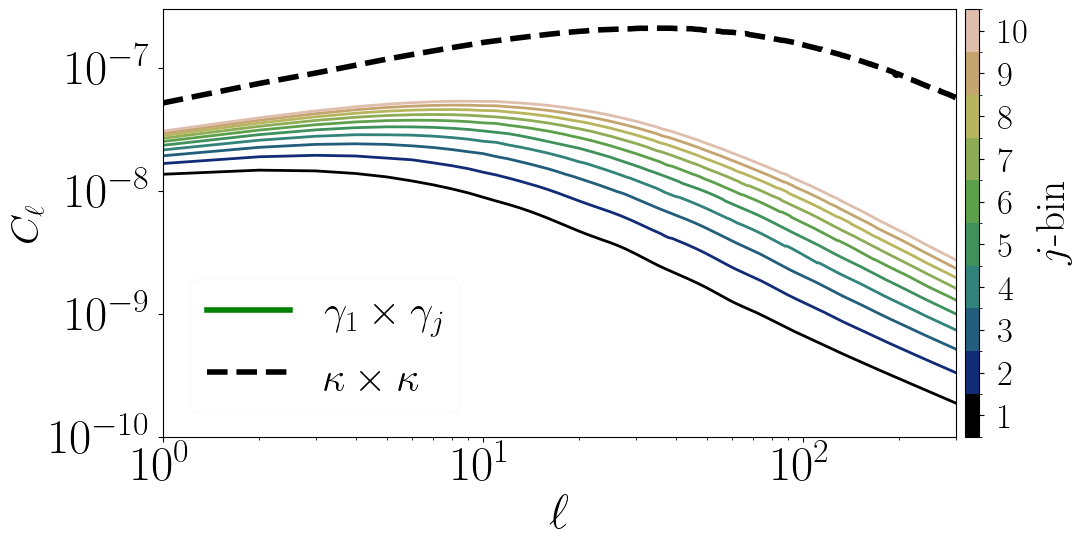

In [28]:
fig   = plt.figure()
grid  = plt.GridSpec(1,1,top=1,right=1.6,wspace=0, hspace=0.0)
ax1   = plt.subplot(grid[0,0])
###############################
N=10
nch  = 10#W_dict['W'].shape[0]
cmap1 = plt.get_cmap("gist_earth", N+1)
c    = np.arange(0, nch+1)
norm = mpl.colors.BoundaryNorm(np.arange(1, N+2,1),N)
sm   = plt.cm.ScalarMappable(norm=norm, cmap=cmap1)


sm.set_array([]) 
#####
A = 1#l*(l+1)  
############################################################################################################
for j,jbin in enumerate( range(Cl_gamma.shape[0]) ):
    ax1.plot(l,A*Cl_gamma[jbin,:],color=cmap1(j),lw=2, ls='solid')
ax1.plot(l,A*Cl_kappa, color=colors[0], lw=4, ls='dashed')

ax1.tick_params(axis='both', labelsize=35),
ax1.set_yscale('log'); ax1.set_xscale('log')
#ax1.set_ylim(0.2e-14, 8e-6);ax2.set_ylim(0.2e-14, 8e-6)
ax1.set_ylabel(r'$C_{\ell}$', fontsize=29); 
ax1.set_xlabel(r'$\ell$', fontsize=35)
ax1.set_xlim([l.min(), l.max()])
cyticks=[1e-7,1e-8,1e-9,1e-10]
ax1.set_yticks(cyticks)
#ax1.set_yticklabels([r'${}$'.format(s) for s in cyticks ]) 
###########################################################
cticks = np.arange(1, N+1,1)#np.linspace(1, len(c)+1, len(c), dtype=np.int8)
cbar   = fig.colorbar(sm,ax=ax1, pad=0.01, aspect=30, ticks=cticks+0.5)
#cbar.locator = MaxNLocator(nbins=N)
#cbar.update_ticks()
cbar.set_label(label=r'$j\textrm{-bin}$',size=30)#,weight='bold')
cticks = np.array([r'${}$'.format(i) for i in cticks])
cbar.ax.set_yticklabels(cticks)
cbar.ax.tick_params(labelsize=25, pad=10);
###########################################################
custom_lines = [Line2D([0], [0], color='g', lw=4, ls='solid'),
                Line2D([0], [0], color='black', lw=4, ls='dashed')]
#
legend_1= ax1.legend(custom_lines, [r'$\gamma_{1} \times \gamma_j$',
                                    r'$\kappa\times\kappa$'],bbox_to_anchor=(0.4, 0.01),
                    fontsize=30,ncols=1,loc='lower right',framealpha=0.1)
###########################################################

In [29]:
z_max = pars_gshear['z_max']
z_min = pars_gshear['z_min']
Cl_gamma = {}
for i, ibin in enumerate(range(Wg['W'].shape[0])):
    timei = time.time()
    Wg_i = kernel_gal_i_dict(ibin=ibin,camb_params=pars, camb_results=results, lens_pars=pars_gshear, verbose=0)
    Wg_i_func  = lambda x: Wg_i['W_interp'](x) if (x>=pars_gshear['z_min'])*(x<=pars_gshear['z_max']) else 0
    W_f1_i = dcopy(Wg_i_func)
    for j, jbin in enumerate(range(Wg['W'].shape[0])):
        Wg_j = kernel_gal_i_dict(ibin=jbin,camb_params=pars, camb_results=results, lens_pars=pars_gshear, verbose=0)
        Wg_j_func  = lambda x: Wg_j['W_interp'](x) if (x>=pars_gshear['z_min'])*(x<=pars_gshear['z_max']) else 0
        W_f2_j = dcopy(Wg_j_func)
        cl_ij_gamma =angular_power_spectrum_ij(camb_params=pars, camb_results=results, 
                                                        W_f1_i=W_f1_i, W_f2_j=W_f2_j, l=l, 
                                                        z_min= z_min, z_max=z_max, verbose=0)['cl']
        Cl_gamma["{}{}".format(i,j)] = dcopy(cl_ij_gamma)
        #if not j: cl_i_gamma = dcopy(cl_ij_gamma)
        #else:     cl_i_gamma = np.vstack(( cl_i_gamma, dcopy(cl_ij_gamma) ))
        del cl_ij_gamma
    #Cl_gamma["{}{}".format(i,j)] = cl_i_gamma
    #if not i: Cl_gamma = dcopy(cl_i_gamma)
    #else:     Cl_gamma = np.vstack(( Cl_gamma, dcopy(cl_i_gamma) ))
    #del cl_i_gamma
    print('Total processing time: {0:.2f} seg'.format(time.time()-timei)) 

Total processing time: 84.08 seg
Total processing time: 81.46 seg
Total processing time: 83.21 seg
Total processing time: 66.61 seg
Total processing time: 68.14 seg
Total processing time: 70.27 seg
Total processing time: 67.52 seg
Total processing time: 48.12 seg
Total processing time: 41.57 seg
Total processing time: 45.94 seg


(1, 300)

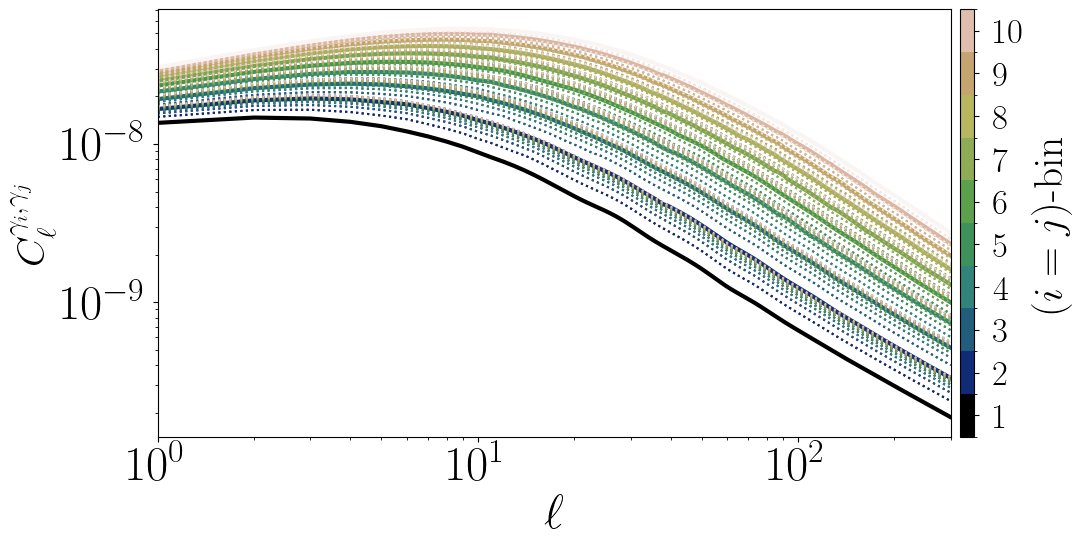

In [30]:
fig   = plt.figure()
grid  = plt.GridSpec(1,1,top=1,right=1.6,wspace=0, hspace=0.0)
ax1   = plt.subplot(grid[0,0])
###############################
n1,N1  = 100,4
###############################
N=100
nch  = 10#W_dict['W'].shape[0]
cmap1 = plt.get_cmap("gist_earth", N+1)
c     = np.arange(0, N+1)
norm1 = mpl.colors.BoundaryNorm(np.arange(1, N+2,1),N)
sm   = plt.cm.ScalarMappable(norm=norm1, cmap=cmap1)
sm.set_array([]) 
#####
cmap2 = plt.get_cmap("gist_earth", nch+1)
c    = np.arange(0, nch+1)
norm2 = mpl.colors.BoundaryNorm(np.arange(1, nch+2,1),nch)
sm   = plt.cm.ScalarMappable(norm=norm2, cmap=cmap2)
#####
A = 1#l*(l+1)  
############################################################################################################
############################################################################################################
I,J = np.arange(nch), np.arange(nch)
I,J = np.meshgrid(I,J)

for num, (i,j) in enumerate(zip(I.flatten(),J.flatten())):   
    if not j: k=0
    else: k+=1
    LS = 'solid' if i==j else 'dotted'
    LW = 3 if i==j else 1.5
    ax1.plot(l,A*Cl_gamma["{}{}".format(i,j)] ,color=cmap1(num),lw=LW, ls=LS)
#ax1.plot(l,A*Cl_gamma["{}{}".format(0,9)] ,color='indigo',lw=4, ls='solid')    
    
#ax1.plot(l,A*Cl_kappa, color=colors[0], lw=4, ls='dashed')
###########################################################
cticks = np.linspace(1, 10,10, dtype=np.int16)
cbar   = fig.colorbar(sm,ax=ax1, pad=0.01, aspect=30, ticks=cticks+0.5)
#cbar.locator = MaxNLocator(nbins=N)
#cbar.update_ticks()
cbar.set_label(label=r'$(i=j)\textrm{-bin}$',size=30)#,weight='bold')
cticks = np.array([r'${}$'.format(i) for i in cticks])
cbar.ax.set_yticklabels(cticks)
cbar.ax.tick_params(labelsize=25, pad=10);
###########################################################

ax1.tick_params(axis='both', labelsize=35),
ax1.set_yscale('log'); ax1.set_xscale('log')
ax1.set_xlim([1,l.max()])
#ax1.set_ylim(0.2e-14, 8e-6);ax2.set_ylim(0.2e-14, 8e-6)
ax1.set_ylabel(r'$C^{\gamma_i, \gamma_j}_{\ell}$', fontsize=29); 
ax1.set_xlabel(r'$\ell$', fontsize=35)
ax1.set_xlim([l.min(), l.max()])

In [31]:
W_lowz_func  = lambda x: kernel_hi(camb_params=pars, camb_results=results, z=x, zrange=z_lowz, config_dict=params_lowz, replace_inf2nan=True)
#W_highz_func = lambda x: kernel_hi(camb_params=pars, camb_results=results, z=x, zrange=z_highz, config_dict=params_highz, replace_inf2nan=True)

In [32]:
params_hi = dcopy(params_lowz)
W_hi      = dcopy(W_lowz_func)
####
W_f1_i = dcopy(W_hi)
Cl_ghi = {}
for i, ibin in enumerate(range(params_hi['z'].size-1)):
    timei = time.time()    
    z_min     = params_hi['z'][i]
    z_max     = params_hi['z'][i+1]
    for j, jbin in enumerate(range(Wg['W'].shape[0])):
        ## field 2
        Wg_j      = kernel_gal_i_dict(ibin=jbin,camb_params=pars, camb_results=results, lens_pars=pars_gshear, verbose=0)
        Wg_j_func = lambda x: Wg_j['W_interp'](x) if (x>=pars_gshear['z_min'])*(x<=pars_gshear['z_max']) else 0
        W_f2_j    = dcopy(Wg_j_func)
        ## cx
        cl_ij = angular_power_spectrum_ij(camb_params=pars, camb_results=results, l=l, 
                                                     W_f1_i=W_f1_i,     W_f2_j=W_f2_j,      
                                                      z_min=z_min,       z_max=z_max, verbose=0)['cl']
        Cl_ghi["{}{}".format(i,j)] = dcopy(cl_ij)
        del cl_ij
    print('Total processing time: {0:.2f} seg'.format(time.time()-timei)) 

Total processing time: 37.65 seg
Total processing time: 38.67 seg
Total processing time: 31.10 seg
Total processing time: 27.08 seg
Total processing time: 38.43 seg
Total processing time: 34.05 seg
Total processing time: 31.93 seg
Total processing time: 35.78 seg
Total processing time: 39.46 seg
Total processing time: 31.71 seg
Total processing time: 26.41 seg
Total processing time: 30.89 seg
Total processing time: 35.11 seg
Total processing time: 26.28 seg
Total processing time: 26.40 seg
Total processing time: 34.22 seg
Total processing time: 38.78 seg
Total processing time: 33.43 seg
Total processing time: 33.11 seg
Total processing time: 26.23 seg
Total processing time: 31.68 seg
Total processing time: 38.30 seg
Total processing time: 33.78 seg
Total processing time: 28.91 seg
Total processing time: 26.98 seg
Total processing time: 38.65 seg
Total processing time: 33.40 seg
Total processing time: 35.15 seg
Total processing time: 36.45 seg
Total processing time: 39.53 seg


In [33]:
params_hi = dcopy(params_lowz)
W_hi      = dcopy(W_lowz_func)
####
W_f1_i = dcopy(W_hi)
Cl_ghi = {}
for i, ibin in enumerate(range(params_hi['z'].size-1)):
    timei = time.time()    
    z_min     = params_hi['z'][i+0]
    z_max     = params_hi['z'][i+1]
    for j, jbin in enumerate(range(Wg['W'].shape[0])):
        ## field 2
        Wg_j      = kernel_gal_i_dict(ibin=jbin,camb_params=pars, 
                                      camb_results=results, 
                                      lens_pars=pars_gshear, verbose=0)
        Wg_j_func = lambda x: Wg_j['W_interp'](x) if (x>=pars_gshear['z_min'])*(x<=pars_gshear['z_max']) else 0
        W_f2_j    = dcopy(Wg_j_func)
        ## cx
        cl_ij = angular_power_spectrum_ij(camb_params=pars, camb_results=results, l=l, 
                                               W_f1_i=W_f1_i,     W_f2_j=W_f2_j,      
                                                z_min=z_min,       z_max=z_max, verbose=0)['cl']
        Cl_ghi["{}{}".format(i,j)] = dcopy(cl_ij)
        del cl_ij
    print('Total processing time: {0:.2f} seg'.format(time.time()-timei)) 

Total processing time: 31.01 seg
Total processing time: 38.73 seg
Total processing time: 34.55 seg
Total processing time: 38.11 seg
Total processing time: 33.91 seg
Total processing time: 34.42 seg
Total processing time: 35.01 seg
Total processing time: 37.26 seg
Total processing time: 38.06 seg
Total processing time: 33.71 seg
Total processing time: 32.75 seg
Total processing time: 27.22 seg
Total processing time: 34.55 seg
Total processing time: 32.25 seg
Total processing time: 36.16 seg
Total processing time: 32.38 seg
Total processing time: 29.30 seg
Total processing time: 35.78 seg
Total processing time: 36.01 seg
Total processing time: 34.65 seg
Total processing time: 34.09 seg
Total processing time: 35.50 seg
Total processing time: 34.84 seg
Total processing time: 32.77 seg
Total processing time: 36.77 seg
Total processing time: 34.83 seg
Total processing time: 32.03 seg
Total processing time: 33.39 seg
Total processing time: 35.65 seg
Total processing time: 34.24 seg


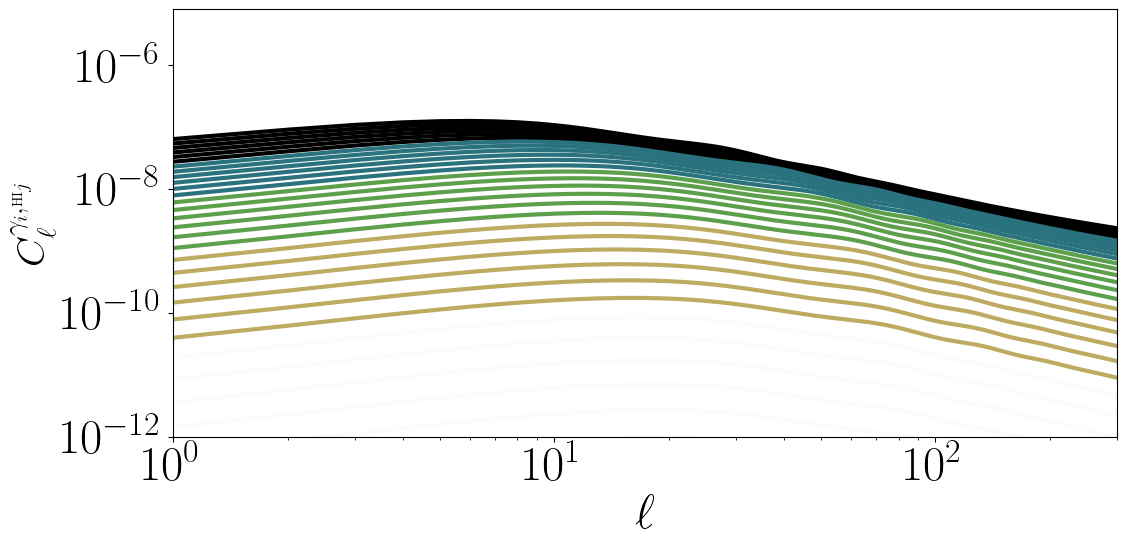

In [34]:
fig   = plt.figure()
grid  = plt.GridSpec(1,1,top=1,right=1.6,wspace=0, hspace=0.0)
ax1   = plt.subplot(grid[0,0])
###############################
n1,N1 = 30,4
n2,N2 = 70,4
n,N  = n1*n2,4
cmap1 = plt.get_cmap("gist_earth", N1+1)
c1 = np.linspace(1, n1, N1, dtype=np.int16)-1
norm1 = mpl.colors.Normalize(vmin=1, vmax=int(n1))
cmap1 = mpl.cm.ScalarMappable(norm=norm1, cmap=cmap1)
cmap1.set_array([])
#####
A = 1#l*(l+1)  
############################################################################################################
I = np.arange(n1)
J = np.arange(n2)

j=0
for num, i in enumerate(I):       
    LS = 'solid' if i==j else 'dotted'
    LW = 3 if i==j else 3
    ax1.plot(l,A*Cl_ghi["{}{}".format(i,j)] ,color=cmap1.to_rgba(num+1),ls='solid', lw=3)
ax1.tick_params(axis='both', labelsize=35),
ax1.set_yscale('log'); ax1.set_xscale('log')
ax1.set_xlim([1,l.max()])
#ax1.set_ylim(0.2e-14, 8e-6);ax2.set_ylim(0.2e-14, 8e-6)
ax1.set_ylabel(r'$C^{\gamma_i, \textrm{\normalsize HI}_j}_{\ell}$', fontsize=29); 
ax1.set_xlabel(r'$\ell$', fontsize=35)
ax1.set_xlim([l.min(), l.max()])
ax1.set_ylim([1e-12, 8e-6]);

(1, 300)

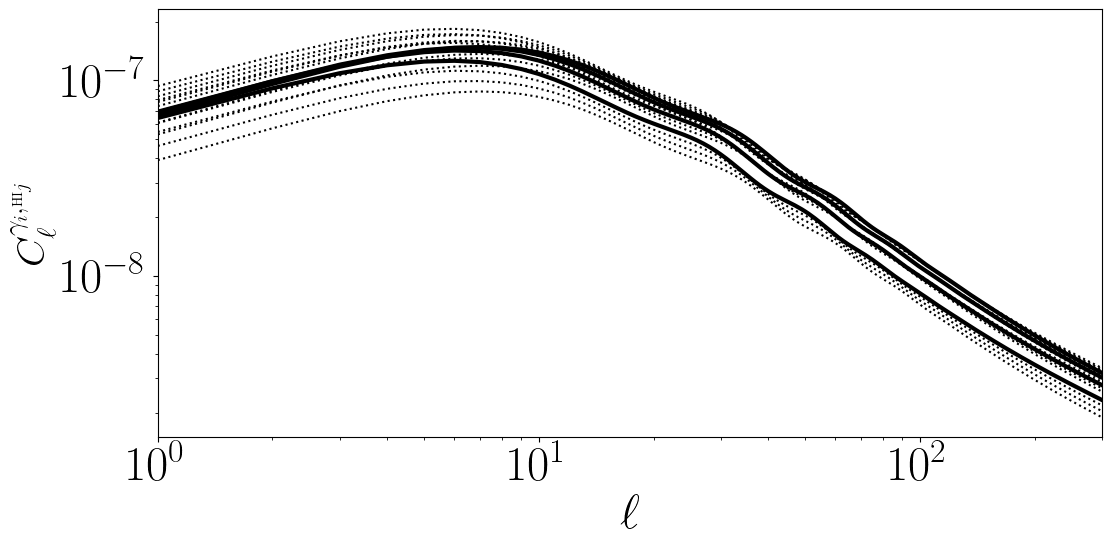

In [35]:
fig   = plt.figure()
grid  = plt.GridSpec(1,1,top=1,right=1.6,wspace=0, hspace=0.0)
ax1   = plt.subplot(grid[0,0])
###############################
n1,N1  = 30*10,4
cmap1 = plt.get_cmap("gist_earth", N+1)
c1 = np.linspace(1, n1, N1, dtype=np.int16)-1
norm1 = mpl.colors.Normalize(vmin=1, vmax=int(n1))
cmap1 = mpl.cm.ScalarMappable(norm=norm1, cmap=cmap1)
cmap1.set_array([])
#####
A = 1#l*(l+1)  
############################################################################################################
I,J = np.arange(N), np.arange(N)
I,J = np.meshgrid(I,J)

for num, (i,j) in enumerate(zip(I.flatten(),J.flatten())):   
    LS = 'solid' if i==j else 'dotted'
    LW = 3 if i==j else 1.5
    ax1.plot(l,A*Cl_ghi["{}{}".format(i,j)] ,color=cmap1.to_rgba(num+1),lw=LW, ls=LS)
#ax1.plot(l,A*Cl_gamma["{}{}".format(0,9)] ,color='indigo',lw=4, ls='solid')    
    
#ax1.plot(l,A*Cl_kappa, color=colors[0], lw=4, ls='dashed')

ax1.tick_params(axis='both', labelsize=35),
ax1.set_yscale('log'); ax1.set_xscale('log')
ax1.set_xlim([1,l.max()])
#ax1.set_ylim(0.2e-14, 8e-6);ax2.set_ylim(0.2e-14, 8e-6)
ax1.set_ylabel(r'$C^{\gamma_i, \textrm{\normalsize HI}_j}_{\ell}$', fontsize=29); 
ax1.set_xlabel(r'$\ell$', fontsize=35)
ax1.set_xlim([l.min(), l.max()])

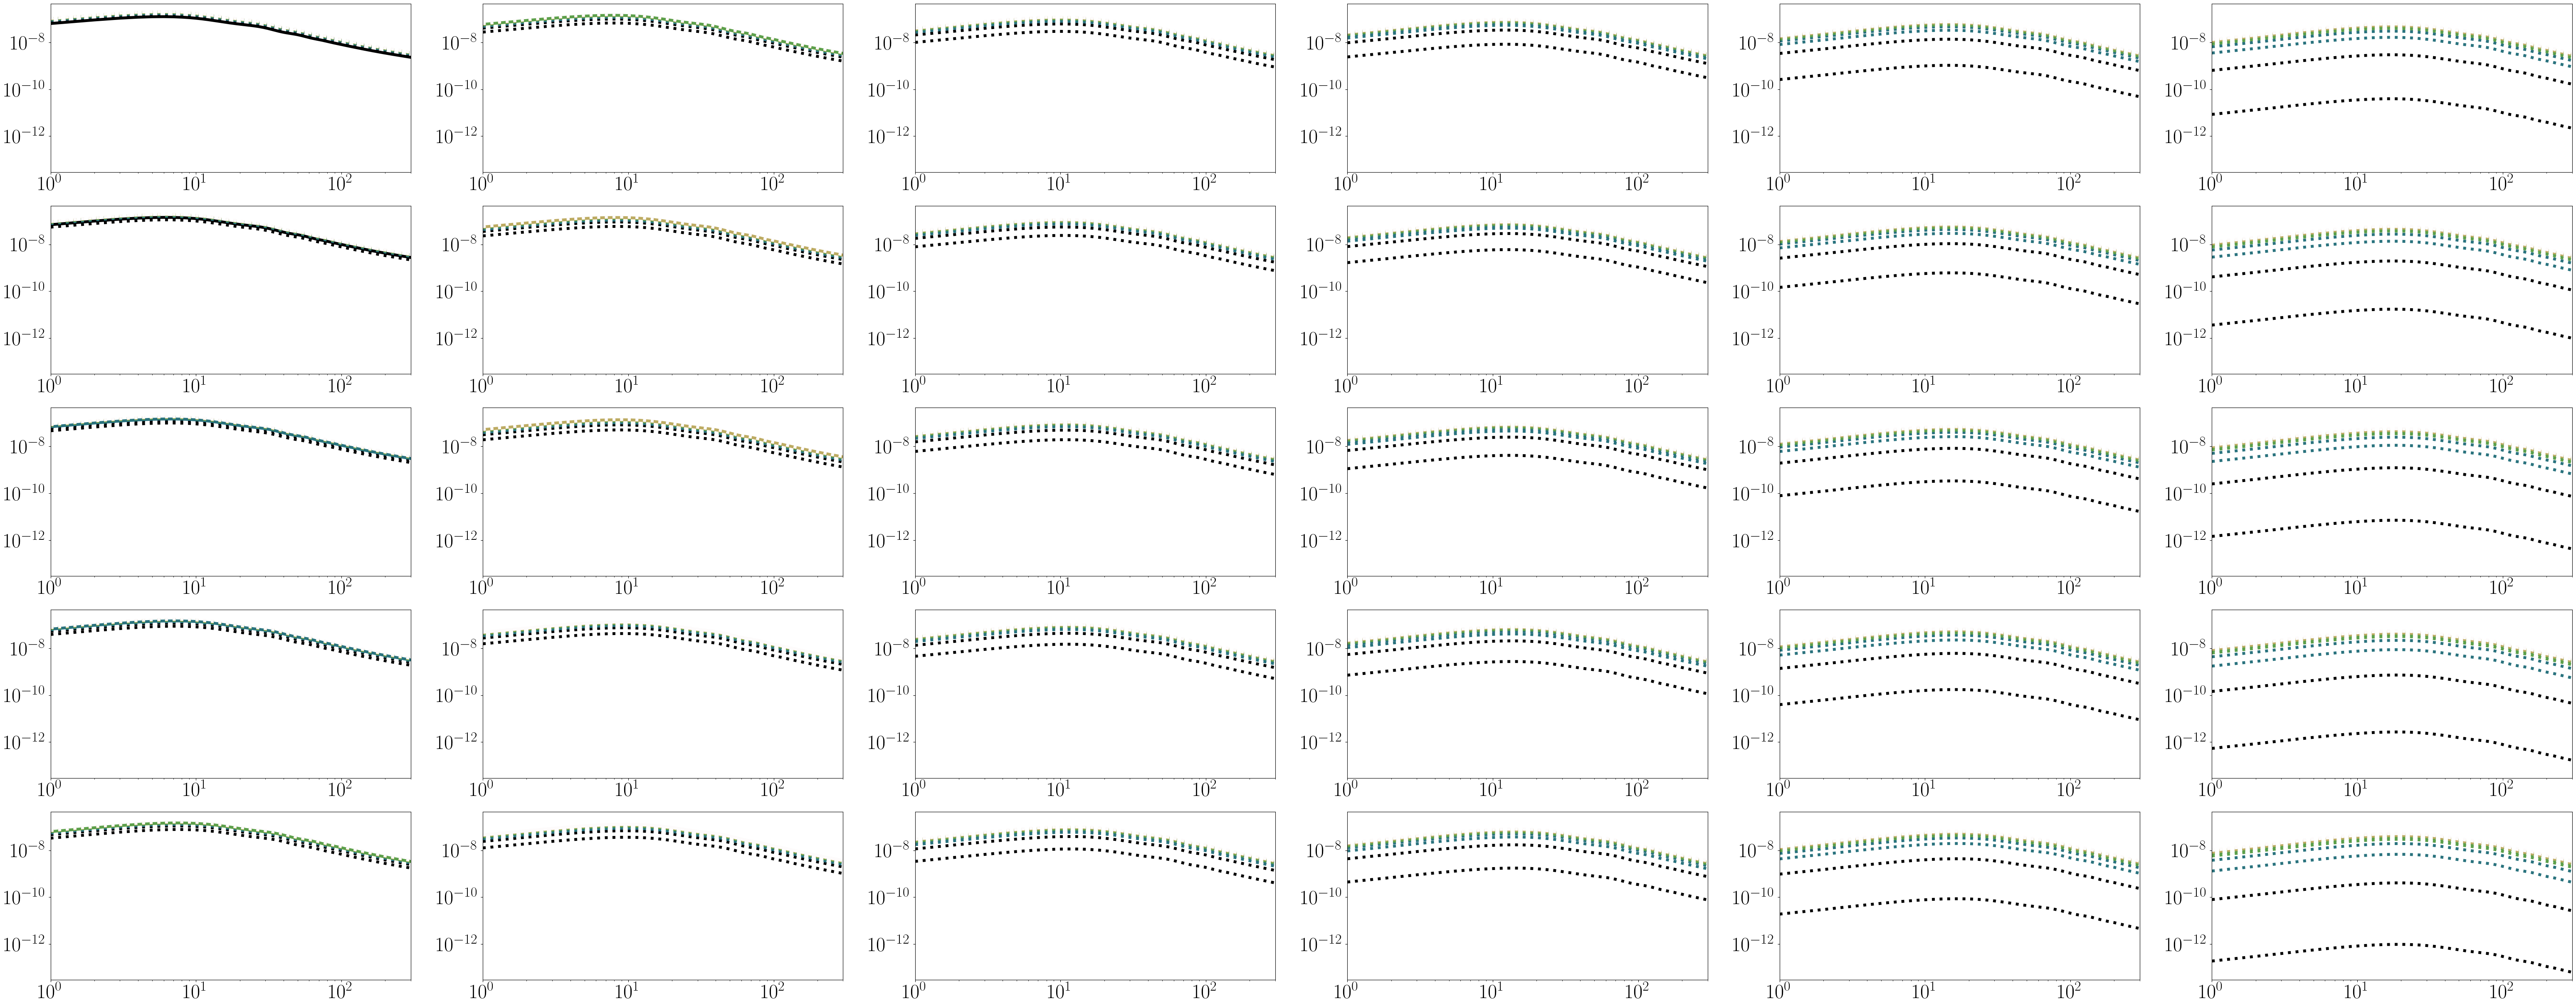

In [36]:
fig   = plt.figure()
nrows, ncols = 5,6
grid  = plt.GridSpec(nrows,ncols,top=1*nrows,right=1.6*ncols)#,wspace=0, hspace=0.0)
###############################
n1,N1  = 10,4
cmap1 = plt.get_cmap("gist_earth", N+1)
c1 = np.linspace(1, n1, N1, dtype=np.int16)-1
norm1 = mpl.colors.Normalize(vmin=1, vmax=int(n1))
cmap1 = mpl.cm.ScalarMappable(norm=norm1, cmap=cmap1)
cmap1.set_array([])
#####
A = 1#l*(l+1)  
############################################################################################################
K1    = np.arange(nrows)
K2    = np.arange(ncols)
K1,K2 = np.meshgrid(K1,K2)
K1,K2 =  K1.flatten(), K2.flatten()

for k, (k1,k2) in enumerate(zip(K1,K2)):
    ax   = plt.subplot(grid[k1,k2]) if not k else plt.subplot(grid[k1,k2], sharex=ax, sharey=ax)
    for j in range(n1):
        LS = 'solid' if j==k else 'dotted'
        LW = 5 if j==k else 5
        ax.plot(l,A*Cl_ghi["{}{}".format(k,j)] ,color=cmap1.to_rgba(j+1),lw=LW, ls=LS)

    ax.tick_params(axis='both', labelsize=35),
    ax.set_yscale('log'); ax.set_xscale('log')
    #ax1.set_ylim(0.2e-14, 8e-6);ax2.set_ylim(0.2e-14, 8e-6)
    #ax.set_ylabel(r'$C^{\gamma_i, \textrm{\normalsize HI}_j}_{\ell}$', fontsize=29); 
    #ax.set_xlabel(r'$\ell$', fontsize=35)
    ax.set_xlim([l.min(), l.max()])

In [ ]:
for j, jsim in enumerate(params_sims['realizations']):
    print('Job {} -- Sim: {}'.format(j+1, jsim))
    lmax        = dict_all[jsim]['alm_hi_sim'][0].real.astype(int).max()
    mmax        = dict_all[jsim]['alm_hi_sim'][1].real.astype(int).max()
    alm_hi_jsim = dict_all[jsim]['alm_hi_sim'][2:]
    for num in range(alm_hi_jsim.shape[0]):
        alm_hi_num = np.ascontiguousarray(alm_hi_jsim[num,:])
        if not num:  Mhi = hp.alm2map( alm_hi_num,                  params_fits.nside, pol=False)    
        else:        Mhi = np.vstack(( Mhi, hp.alm2map( alm_hi_num, params_fits.nside, pol=False) ))       
    ###
    params_maps["getdata"] = "observed"
    #subdirs = cs.checkdir(params_path_cs.pathout, subdirs=["21cm","foregrounds","mixmatrix"],restart=True)
    params_cs, params_wt = cs.load(params_CS,params_WT)
    X = dcopy(Mhi + Mfg)*MASK
    X = cs.adaptation_maps(X, params_maps, params_path)
    Xr = cs.maps2CSmaps(    X, params_wt  , params_cs)
    ######
    jseed = jsim.split('sim')[1]
    output_info['pathout_dir'] = os.path.join(output_info['pathout'],str(jsim))
    #####
    for i, (ifield_name, ifield_data) in enumerate(zip(['extHI', 'extFG','mixmatrix'],
                                                       [Xr['reconstruction']['21cm'], Xr['reconstruction']['foregrounds'], Xr["mixmatrix"] ]
                                                      )
                                                   ):
        output_info['field']        = ifield_name
        output_info['irealization'] = cxft.get_Lformat(L_=jseed)    
        jfilename = dcopy(output_info['filename'].replace('L',output_info['irealization']))
        jfilename = jfilename.replace('field', output_info['field'])
        output_info['pathout_field'] = os.path.join(output_info['pathout_dir'], jfilename)    
        hdata.file_verification(output_info['pathout'],output_info['filename'],str(jsim))
        cxft.savefits(data_=ifield_data, params_=output_info, save_mixmatrix=True, S_mixmatrix=Xr['mixmatrix'])
    print()